In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score




In [3]:
#softmax function

def softmax(z):
    """
    z: shape (n_samples, n_classes)
    Returns: probabilities shape (n_samples, n_classes)
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [4]:
#cost function

def cost_softmax(X, y_onehot, W, b):
    """
    X:        (n, d)
    y_onehot: (n, c) one-hot encoded
    W:        (d, c)
    b:        (c,)
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    # Avoid log(0) → small epsilon
    return -np.sum(y_onehot * np.log(y_pred + 1e-12)) / n

In [5]:
#compute gradients

def compute_gradient_softmax(X, y_onehot, W, b):
    """
    Returns: grad_W (d,c), grad_b (c,)
    """
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    error = y_pred - y_onehot
    grad_W = np.dot(X.T, error) / n
    grad_b = np.sum(error, axis=0) / n
    return grad_W, grad_b

In [6]:
#graident descent

def gradient_descent_softmax(X, y_onehot, W_init, b_init, alpha, n_iter, print_every=100):
    """
    Returns: W_opt, b_opt, cost_history
    """
    W = W_init.copy()
    b = b_init.copy()
    cost_history = []
    
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y_onehot, W, b)
        W -= alpha * grad_W
        b -= alpha * grad_b
        
        cost = cost_softmax(X, y_onehot, W, b)
        cost_history.append(cost)
        
        if i % print_every == 0 or i == n_iter - 1:
            print(f"Iter {i:5d} | Cost = {cost:.6f}")
    
    return W, b, cost_history

In [7]:
#prediction fuctions

def predict_softmax(X, W, b):
    """ Returns class indices (0,1,2,...) """
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

Iris dataset loaded.
Features shape: (150, 4)
Target classes: [0 1 2]

Train: (120, 4), Test: (30, 4)

Training with α = 0.3, iterations = 1500
Iter     0 | Cost = 0.850067
Iter   200 | Cost = 0.150633
Iter   400 | Cost = 0.107092
Iter   600 | Cost = 0.089289
Iter   800 | Cost = 0.079444
Iter  1000 | Cost = 0.073114
Iter  1200 | Cost = 0.068659
Iter  1400 | Cost = 0.065328
Iter  1499 | Cost = 0.063968


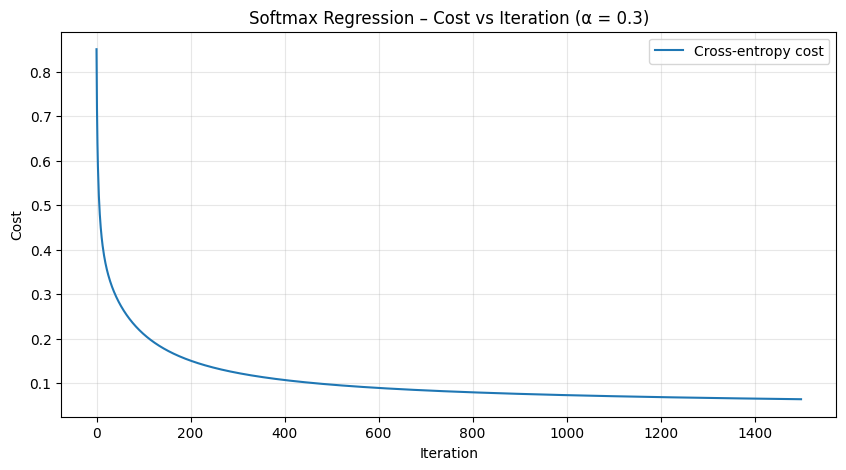


FINAL RESULTS
Train Cost:     0.063968
Test  Cost:     0.090525
Train Accuracy: 97.50%
Test  Accuracy: 96.67%

Confusion Matrix (test set):
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Precision: 0.970
Recall:    0.967
F1-Score:  0.967


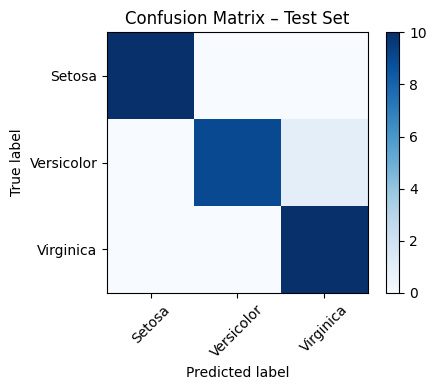

In [8]:
def main():
    # Load Iris
    iris = load_iris()
    X = iris.data          # (150, 4)
    y = iris.target        # (150,) integers 0,1,2
    
    print("Iris dataset loaded.")
    print("Features shape:", X.shape)
    print("Target classes:", np.unique(y))
    
    # One-hot encode targets
    encoder = OneHotEncoder(sparse_output=False)
    y_onehot = encoder.fit_transform(y.reshape(-1, 1))  # (150, 3)
    
    # Train-test split with stratification
    X_train_raw, X_test_raw, y_train_onehot, y_test_onehot = train_test_split(
        X, y_onehot, test_size=0.2, random_state=42, stratify=y
    )
    
    # Feature scaling (very important!)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)
    
    print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
    
    # ─── Initialize parameters ───
    n_features = X_train.shape[1]   # 4
    n_classes  = y_train_onehot.shape[1]  # 3
    W = np.zeros((n_features, n_classes))
    b = np.zeros(n_classes)
    
    # Hyperparameters (you can experiment here)
    alpha   = 0.3      # learning rate
    n_iter  = 1500     # number of iterations
    
    print(f"\nTraining with α = {alpha}, iterations = {n_iter}")
    
    # Train model
    W_opt, b_opt, cost_history = gradient_descent_softmax(
        X_train, y_train_onehot, W, b, alpha, n_iter, print_every=200
    )
    
    # ─── Plot cost history ───
    plt.figure(figsize=(10, 5))
    plt.plot(cost_history, label='Cross-entropy cost')
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title(f'Softmax Regression – Cost vs Iteration (α = {alpha})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # ─── Predictions ───
    y_train_pred = predict_softmax(X_train, W_opt, b_opt)
    y_test_pred  = predict_softmax(X_test,  W_opt, b_opt)
    
    y_train_true = np.argmax(y_train_onehot, axis=1)
    y_test_true  = np.argmax(y_test_onehot, axis=1)
    
    # ─── Evaluation ───
    train_cost = cost_softmax(X_train, y_train_onehot, W_opt, b_opt)
    test_cost  = cost_softmax(X_test,  y_test_onehot,  W_opt, b_opt)
    
    train_acc = np.mean(y_train_pred == y_train_true) * 100
    test_acc  = np.mean(y_test_pred  == y_test_true)  * 100
    
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Train Cost:     {train_cost:.6f}")
    print(f"Test  Cost:     {test_cost:.6f}")
    print(f"Train Accuracy: {train_acc:.2f}%")
    print(f"Test  Accuracy: {test_acc:.2f}%")
    
    # Confusion matrix & metrics
    cm = confusion_matrix(y_test_true, y_test_pred)
    precision = precision_score(y_test_true, y_test_pred, average='weighted', zero_division=0)
    recall    = recall_score(   y_test_true, y_test_pred, average='weighted', zero_division=0)
    f1        = f1_score(       y_test_true, y_test_pred, average='weighted', zero_division=0)
    
    print("\nConfusion Matrix (test set):")
    print(cm)
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-Score:  {f1:.3f}")
    
    # Optional: Visualize confusion matrix
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title("Confusion Matrix – Test Set")
    plt.colorbar()
    tick_marks = np.arange(3)
    plt.xticks(tick_marks, ['Setosa', 'Versicolor', 'Virginica'], rotation=45)
    plt.yticks(tick_marks, ['Setosa', 'Versicolor', 'Virginica'])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


# Run everything
if __name__ == "__main__":
    main()